In [2]:
from transformers import AutoTokenizer
from pubmed_loader import PubMedQAData

# Loading Data
data = PubMedQAData('data').train_set
tokenizer = AutoTokenizer.from_pretrained("microsoft/BiomedNLP-BiomedBERT-base-uncased-abstract")

word_list = []
for pmid, item in data.items():
    context = " ".join(item["CONTEXTS"])
    tokens = tokenizer(context)["input_ids"]
    word_list.append(len(tokens))

print(f"Total sample size: {len(word_list)}")
print(f"Average length: {sum(word_list)/len(word_list):.0f}")
print(f"Median:: {sorted(word_list)[len(word_list)//2]}")
print(f"Percentage over 512: {sum(1 for l in word_list if l > 512)/len(word_list)*100:.1f}%")
print(f"Max length: {max(word_list)}")
print(f"Min length: {min(word_list)}")

e:\Anaconda\envs\text_analytics\Lib\site-packages\transformers\utils\hub.py:110: FutureWarning: Using `TRANSFORMERS_CACHE` is deprecated and will be removed in v5 of Transformers. Use `HF_HOME` instead.
  warnings.warn(


Total sample size: 450
Average length: 274
Median:: 272
Percentage over 512: 0.4%
Max length: 586
Min length: 57


In [2]:
import gensim

#model_BioWordVec = gensim.models.KeyedVectors.load_word2vec_format(
#    "BioWordVec_PubMed_MIMICIII_d200.bin", binary=True
#)

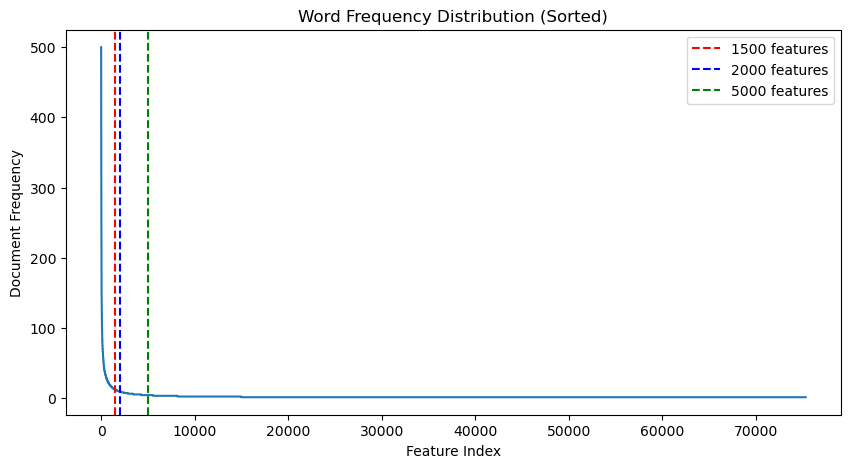

In [6]:
from sklearn.feature_extraction.text import TfidfVectorizer
from matplotlib import pyplot as plt
import numpy as np
from pubmed_loader import PubMedQAData
from preprocessing import preprocess_tfidf

data = PubMedQAData("data")

train_texts, train_labels = preprocess_tfidf(data.train_set, use_mesh=True)
dev_texts, dev_labels = preprocess_tfidf(data.dev_set, use_mesh=True)
test_texts, test_labels = preprocess_tfidf(data.test_set, use_mesh=True)

combined_texts = train_texts + dev_texts

full_vectorizer = TfidfVectorizer(ngram_range=(1, 2))
X_full = full_vectorizer.fit_transform(combined_texts)

df_counts = (X_full > 0).sum(axis=0).tolist()[0]
df_counts.sort(reverse=True)

plt.figure(figsize=(10, 5))
plt.plot(df_counts)
plt.title("Word Frequency Distribution (Sorted)")
plt.xlabel("Feature Index")
plt.ylabel("Document Frequency")
plt.axvline(x=1500, color='r', linestyle='--', label='1500 features')
plt.axvline(x=2000, color='b', linestyle='--', label='2000 features')
plt.axvline(x=5000, color='g', linestyle='--', label='5000 features')
plt.legend()
plt.show()